# Black-Litterman Model: Incorporando Views Subjetivas

## O Problema do Markowitz Clássico

No notebook anterior, usamos retornos esperados **arbitrários**:
- Ativo 1: 10% a.a.
- Ativo 2: 15% a.a.
- Ativo 3: 8% a.a.

**Mas como sabemos esses valores?**

### Problemas na Prática:

1. **Retornos históricos** → Otimizador gera alocações extremas
2. **Estimativas subjetivas** → Muito arbitrárias
3. **Sensibilidade** → Pequena mudança em μ → portfólio completamente diferente

## A Solução: Black-Litterman (1992)

Criado por Fischer Black e Robert Litterman no Goldman Sachs.

### Ideia Central:

$$\text{Retornos Finais} = \underbrace{\text{Equilíbrio de Mercado}}_{\text{Prior Bayesiano}} + \underbrace{\text{Suas Opiniões}}_{\text{Views}}$$

### Vantagens:

 Portfólios mais **estáveis** e **diversificados**  
 Incorpora **conhecimento do mercado**  
 Permite expressar **views subjetivas** de forma rigorosa  
 Framework **bayesiano** estatisticamente correto

---

In [1]:
# Bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [2]:
"""
📊 RECRIAR DADOS DO NOTEBOOK 1

Vamos gerar os mesmos dados para manter consistência
"""

np.random.seed(42)
n_dias = 252  # 1 ano de pregões

# Simular retornos dos 3 ativos (mesmos do notebook 1)
retornos = np.random.multivariate_normal(
    mean=[0.10/252, 0.15/252, 0.08/252],
    cov=[[0.20**2/252, 0.5*0.20*0.30/252, -0.2*0.20*0.15/252],
         [0.5*0.20*0.30/252, 0.30**2/252, -0.1*0.30*0.15/252],
         [-0.2*0.20*0.15/252, -0.1*0.30*0.15/252, 0.15**2/252]],
    size=n_dias
)

# Organizar em DataFrame
df_retornos = pd.DataFrame(retornos, columns=['Ativo_1', 'Ativo_2', 'Ativo_3'])

# Calcular estatísticas anualizadas
mu_historico = df_retornos.mean() * 252
Sigma = df_retornos.cov() * 252

print("="*70)
print("📊 DADOS BASE (mesmos do Notebook 1)")
print("="*70)

print("\n📈 RETORNOS ESPERADOS (históricos):")
for ativo, ret in mu_historico.items():
    print(f"   {ativo}: {ret:.2%}")

print("\n📊 MATRIZ DE COVARIÂNCIA:")
print(Sigma.round(4))

print("\n📊 MATRIZ DE CORRELAÇÃO:")
print(df_retornos.corr().round(3))

print("\n✅ Dados recriados com sucesso!")
print("="*70)

📊 DADOS BASE (mesmos do Notebook 1)

📈 RETORNOS ESPERADOS (históricos):
   Ativo_1: -29.46%
   Ativo_2: 2.38%
   Ativo_3: 36.79%

📊 MATRIZ DE COVARIÂNCIA:
         Ativo_1  Ativo_2  Ativo_3
Ativo_1   0.0348   0.0221  -0.0043
Ativo_2   0.0221   0.0742  -0.0008
Ativo_3  -0.0043  -0.0008   0.0253

📊 MATRIZ DE CORRELAÇÃO:
         Ativo_1  Ativo_2  Ativo_3
Ativo_1    1.000    0.434   -0.146
Ativo_2    0.434    1.000   -0.019
Ativo_3   -0.146   -0.019    1.000

✅ Dados recriados com sucesso!


## 1. Prior Bayesiano: Retornos de Equilíbrio

### Pergunta fundamental:

**Se o mercado está em equilíbrio, quais retornos os ativos DEVEM ter?**

### CAPM Reverso:

O Black-Litterman usa **reverse optimization** baseado no CAPM:

$$\Pi = \delta \Sigma w_{\text{mkt}}$$

Onde:
- $\Pi$ = vetor de retornos de equilíbrio implícitos
- $\delta$ = coeficiente de aversão ao risco do mercado
- $\Sigma$ = matriz de covariância
- $w_{\text{mkt}}$ = pesos de mercado (market cap ponderado)

### Intuição:

Se os pesos de mercado são $w_{\text{mkt}}$, e o mercado é racional, então os retornos esperados devem ser aqueles que **justificam** esses pesos como ótimos.

### Coeficiente de Aversão ao Risco $\delta$:

$$\delta = \frac{E[R_{\text{mkt}}] - R_f}{\sigma^2_{\text{mkt}}}$$

Tipicamente $\delta \approx 2.5$ para mercados desenvolvidos.

 **CONCEITO ESTATÍSTICO:**  
Isso é uma aplicação do **Teorema de Bayes** em espaço contínuo. O prior não é uma distribuição pontual, mas uma distribuição sobre os retornos esperados.

In [3]:
"""
📐 CALCULAR RETORNOS DE EQUILÍBRIO (PRIOR)

Vamos assumir que os pesos de mercado são proporcionais
à capitalização de mercado (market cap).
"""

# PASSO 1: Definir pesos de mercado
# Na prática, você obteria do mercado (market cap de cada ativo)
# Aqui vamos simular valores realistas

market_caps = np.array([100, 150, 80])  # Bilhões (exemplo)
w_mkt = market_caps / market_caps.sum()  # Normalizar

print("="*70)
print("📊 PASSO 1: PESOS DE MERCADO")
print("="*70)
print(f"\nMarket Caps simuladas: {market_caps}")
print(f"\nPesos de mercado (w_mkt):")
for i, (ativo, peso) in enumerate(zip(['Ativo_1', 'Ativo_2', 'Ativo_3'], w_mkt)):
    print(f"   {ativo}: {peso:.1%} (market cap: {market_caps[i]}B)")

mu_array = mu_historico.values
R_mkt = w_mkt @ mu_array
var_mkt = w_mkt @ Sigma.values @ w_mkt
Rf = 0.02 
delta = (R_mkt - Rf) / var_mkt

print("\n" + "="*70)
print(" COEFICIENTE DE AVERSÃO AO RISCO")
print("="*70)
print(f"\nRetorno do mercado (w_mkt): {R_mkt:.2%}")
print(f"Variância do mercado: {var_mkt:.4f}")
print(f"Taxa livre de risco: {Rf:.2%}")
print(f"\n➡️ Delta (δ): {delta:.2f}")
print(f"   Interpretação: Investidor típico requer {delta:.1f}% de retorno extra")
print(f"   para cada 1% de variância adicional")

# PASSO 3: Calcular retornos de equilíbrio (PRIOR)
# Π = δ * Σ * w_mkt

Pi = delta * (Sigma.values @ w_mkt)  # Retornos implícitos de equilíbrio (NumPy array)

print("\n" + "="*70)
print("📊 PASSO 3: RETORNOS DE EQUILÍBRIO (PRIOR BAYESIANO)")
print("="*70)

print("\n📈 Comparação: Retornos Históricos vs Equilíbrio")
print("-"*70)
print(f"{'Ativo':<15} {'Histórico':>15} {'Equilíbrio':>15} {'Diferença':>15}")
print("-"*70)

for i, ativo in enumerate(['Ativo_1', 'Ativo_2', 'Ativo_3']):
    hist = mu_historico.iloc[i]
    equil = Pi[i]  # Pi é NumPy array, usa índice numérico
    diff = equil - hist
    print(f"{ativo:<15} {hist:>14.2%} {equil:>14.2%} {diff:>14.2%}")

print("-"*70)

print("\n💡 INTERPRETAÇÃO:")
print("   • Retornos de EQUILÍBRIO = prior bayesiano")
print("   • Baseados nos pesos de mercado atuais")
print("   • Assumem que o mercado está precificado corretamente")
print("   • Servem como 'ponto de partida' antes de adicionar views")
print("="*70)

📊 PASSO 1: PESOS DE MERCADO

Market Caps simuladas: [100 150  80]

Pesos de mercado (w_mkt):
   Ativo_1: 30.3% (market cap: 100B)
   Ativo_2: 45.5% (market cap: 150B)
   Ativo_3: 24.2% (market cap: 80B)

 COEFICIENTE DE AVERSÃO AO RISCO

Retorno do mercado (w_mkt): 1.07%
Variância do mercado: 0.0253
Taxa livre de risco: 2.00%

➡️ Delta (δ): -0.37
   Interpretação: Investidor típico requer -0.4% de retorno extra
   para cada 1% de variância adicional

📊 PASSO 3: RETORNOS DE EQUILÍBRIO (PRIOR BAYESIANO)

📈 Comparação: Retornos Históricos vs Equilíbrio
----------------------------------------------------------------------
Ativo                 Histórico      Equilíbrio       Diferença
----------------------------------------------------------------------
Ativo_1                -29.46%         -0.71%         28.74%
Ativo_2                  2.38%         -1.47%         -3.86%
Ativo_3                 36.79%         -0.16%        -36.95%
-------------------------------------------------------

## 2. Views: Incorporando Opiniões Subjetivas

### O que são "Views"?

Views são **opiniões** que você tem sobre retornos futuros dos ativos.

### Tipos de Views:

**1. View Absoluta:**
> "Ativo 1 vai ter retorno de 18% no próximo ano"

**2. View Relativa:**
> "Ativo 2 vai performar 5% melhor que Ativo 3"

**3. View Combinada:**
> "Uma carteira 50% Ativo 1 + 50% Ativo 2 vai retornar 12%"

### Framework Matemático:

Views são expressas como:

$$P \mu = Q + \epsilon$$

Onde:
- $P$ = **matriz de picking** (k × n) - identifica quais ativos estão na view
- $Q$ = **vetor de views** (k × 1) - os retornos que você acredita
- $\epsilon \sim N(0, \Omega)$ - erro/incerteza nas views
- $\Omega$ = **matriz de incerteza** das views (quanto você confia)

### Exemplo:

**View:** "Ativo 2 vai superar Ativo 3 em 6%"

$$
\begin{aligned}
P &= \begin{bmatrix} 0 & 1 & -1 \end{bmatrix} \quad \text{(0} \times \text{Ativo}_1 + 1 \times \text{Ativo}_2 - 1 \times \text{Ativo}_3\text{)} \\
Q &= \begin{bmatrix} 0.06 \end{bmatrix} \quad \text{(diferença de 6\%)} \\
\Omega &= \begin{bmatrix} 0.0001 \end{bmatrix} \quad \text{(confiança na view)}
\end{aligned}
$$

 **CONCEITO BAYESIANO:**  
Views são tratadas como **observações ruidosas** da verdadeira distribuição de retornos.  
Menor $\Omega$ = maior confiança = view tem mais peso na atualização.

In [4]:
"""
📊 DEFININDO VIEWS SUBJETIVAS

Vamos criar 2 views de exemplo:
1. View Absoluta: "Ativo 1 vai retornar 14%"
2. View Relativa: "Ativo 2 vai superar Ativo 3 em 6%"
"""

# Número de views e ativos
n_ativos = 3
n_views = 2

print("="*70)
print("📊 DEFININDO VIEWS")
print("="*70)

# VIEW 1: Absoluta - "Ativo 1 vai retornar 14%"
# P[0] = [1, 0, 0] → pega só o Ativo_1
# Q[0] = 0.14 → retorno esperado de 14%

print("\n🎯 VIEW 1 (Absoluta):")
print("   'Ativo_1 vai retornar 14% ao ano'")
print("   ")
print("   Matemática: 1×Ativo_1 + 0×Ativo_2 + 0×Ativo_3 = 0.14")

# VIEW 2: Relativa - "Ativo 2 vai superar Ativo 3 em 6%"
# P[1] = [0, 1, -1] → diferença entre Ativo_2 e Ativo_3
# Q[1] = 0.06 → diferença de 6%

print("\n🎯 VIEW 2 (Relativa):")
print("   'Ativo_2 vai superar Ativo_3 em 6%'")
print("   ")
print("   Matemática: 0×Ativo_1 + 1×Ativo_2 - 1×Ativo_3 = 0.06")

# MATRIZ P (picking matrix) - 2x3
# Cada linha é uma view
P = np.array([
    [1, 0, 0],    # View 1: pega Ativo_1
    [0, 1, -1]    # View 2: Ativo_2 - Ativo_3
])

# VETOR Q (view returns) - 2x1
Q = np.array([0.14, 0.06])  # 14% e 6%

print("\n" + "="*70)
print("📐 REPRESENTAÇÃO MATEMÁTICA")
print("="*70)

print("\n📊 MATRIZ P (picking matrix):")
print("         Ativo_1  Ativo_2  Ativo_3")
for i, view_num in enumerate(['View 1', 'View 2']):
    print(f"{view_num}:  {P[i,0]:>6}   {P[i,1]:>6}   {P[i,2]:>6}")

print("\n📊 VETOR Q (expected returns das views):")
for i, (view_num, val) in enumerate(zip(['View 1', 'View 2'], Q)):
    print(f"{view_num}: {val:.1%}")

# MATRIZ OMEGA (incerteza nas views)
# Quanto MENOR o valor, MAIOR a confiança
# Regra prática: Ω ≈ τ * P * Σ * P^T (para views proporcionais à incerteza do mercado)
# Ou definir manualmente baseado na confiança

tau = 0.025  # Parâmetro de escala (típico: 0.025 a 0.05)

# Método 1: Proporcional à incerteza do mercado
Omega_auto = tau * (P @ Sigma.values @ P.T)

# Método 2: Manual (vamos usar confiança média)
# Quanto menor, mais confiante você está
Omega_manual = np.diag([0.0001, 0.0002])  # View 1 mais confiante que View 2

# Vamos usar o método proporcional
Omega = Omega_auto

print("\n📊 MATRIZ OMEGA (incerteza nas views):")
print("     View_1     View_2")
for i, view_num in enumerate(['View 1', 'View 2']):
    print(f"{view_num}: {Omega[i,0]:.6f}  {Omega[i,1]:.6f}")

print("\n💡 INTERPRETAÇÃO DE OMEGA:")
print("   • Valores PEQUENOS → ALTA confiança na view")
print("   • Valores GRANDES → BAIXA confiança na view")
print("   • Diagonal = views são independentes entre si")

print("\n" + "="*70)
print("✅ VIEWS DEFINIDAS!")
print("="*70)

print("\n📋 RESUMO:")
print(f"   • {n_views} views sobre {n_ativos} ativos")
print(f"   • Tau (escala): {tau}")
print(f"   • Próximo passo: combinar Prior (equilíbrio) + Views → Posterior")

📊 DEFININDO VIEWS

🎯 VIEW 1 (Absoluta):
   'Ativo_1 vai retornar 14% ao ano'
   
   Matemática: 1×Ativo_1 + 0×Ativo_2 + 0×Ativo_3 = 0.14

🎯 VIEW 2 (Relativa):
   'Ativo_2 vai superar Ativo_3 em 6%'
   
   Matemática: 0×Ativo_1 + 1×Ativo_2 - 1×Ativo_3 = 0.06

📐 REPRESENTAÇÃO MATEMÁTICA

📊 MATRIZ P (picking matrix):
         Ativo_1  Ativo_2  Ativo_3
View 1:       1        0        0
View 2:       0        1       -1

📊 VETOR Q (expected returns das views):
View 1: 14.0%
View 2: 6.0%

📊 MATRIZ OMEGA (incerteza nas views):
     View_1     View_2
View 1: 0.000869  0.000660
View 2: 0.000660  0.002526

💡 INTERPRETAÇÃO DE OMEGA:
   • Valores PEQUENOS → ALTA confiança na view
   • Valores GRANDES → BAIXA confiança na view
   • Diagonal = views são independentes entre si

✅ VIEWS DEFINIDAS!

📋 RESUMO:
   • 2 views sobre 3 ativos
   • Tau (escala): 0.025
   • Próximo passo: combinar Prior (equilíbrio) + Views → Posterior


## 3. Atualização Bayesiana: Combinando Prior + Views

### A Fórmula Black-Litterman:

$$\mu_{BL} = \Pi + \tau \Sigma P^T (P \tau \Sigma P^T + \Omega)^{-1} (Q - P\Pi)$$

### Decompondo cada termo:

| Termo | Dimensão | Significado |
|-------|----------|-------------|
| $\mu_{BL}$ | (n × 1) | Retornos esperados FINAIS (posterior) |
| $\Pi$ | (n × 1) | Retornos de equilíbrio (prior) |
| $\tau$ | escalar | Fator de escala (~0.025) |
| $\Sigma$ | (n × n) | Matriz de covariância |
| $P$ | (k × n) | Matriz de picking (views) |
| $\Omega$ | (k × k) | Incerteza nas views |
| $Q$ | (k × 1) | Retornos esperados das views |

### Intuição:

$$
\underbrace{\mu_{BL}}_{\substack{\text{Crença} \\ \text{Final}}} = \underbrace{\Pi}_{\substack{\text{Prior} \\ \text{(equilíbrio)}}} + \underbrace{\text{Ajuste baseado nas Views}}_{\substack{\text{Quanto desviar} \\ \text{do equilíbrio}}}
$$

**Se suas views concordam com equilíbrio:** $Q \approx P\Pi$ → ajuste pequeno  
**Se suas views discordam muito:** $Q \neq P\Pi$ → ajuste grande

**Se você tem alta confiança:** $\Omega$ pequeno → views têm mais peso  
**Se você tem baixa confiança:** $\Omega$ grande → prior tem mais peso

In [5]:
"""
🎯 IMPLEMENTAÇÃO DA FÓRMULA BLACK-LITTERMAN

μ_BL = Π + τ·Σ·P^T·(P·τ·Σ·P^T + Ω)^(-1)·(Q - P·Π)

Vamos calcular passo a passo para entender cada termo.
"""

print("="*70)
print("🎯 CALCULANDO BLACK-LITTERMAN")
print("="*70)

# Converter Sigma para NumPy array
Sigma_array = Sigma.values

# PASSO 1: Calcular τ·Σ
tau_Sigma = tau * Sigma_array

print(f"\n1️⃣ PASSO 1: τ·Σ")
print(f"   tau = {tau}")
print(f"   Dimensão: (3×3)")

# PASSO 2: Calcular P·τ·Σ·P^T
P_tau_Sigma_PT = P @ tau_Sigma @ P.T

print(f"\n2️⃣ PASSO 2: P·τ·Σ·P^T")
print(f"   Dimensão: (2×2) [número de views × número de views]")
print(f"   Resultado:")
print(P_tau_Sigma_PT)

# PASSO 3: Adicionar Ω e inverter
matriz_inverter = P_tau_Sigma_PT + Omega
matriz_invertida = np.linalg.inv(matriz_inverter)

print(f"\n3️⃣ PASSO 3: (P·τ·Σ·P^T + Ω)^(-1)")
print(f"   P·τ·Σ·P^T + Ω:")
print(matriz_inverter)
print(f"\n   Inversa:")
print(matriz_invertida)

# PASSO 4: Calcular (Q - P·Π)
diferenca_views = Q - (P @ Pi)

print(f"\n4️⃣ PASSO 4: (Q - P·Π)")
print(f"   Q (suas views):")
for i, val in enumerate(Q):
    print(f"      View {i+1}: {val:.2%}")

print(f"\n   P·Π (views implícitas no equilíbrio):")
equilibrio_views = P @ Pi
for i, val in enumerate(equilibrio_views):
    print(f"      View {i+1}: {val:.2%}")

print(f"\n   Diferença (Q - P·Π):")
for i, val in enumerate(diferenca_views):
    print(f"      View {i+1}: {val:+.2%}")

print("\n   💡 Quanto maior a diferença, mais o BL vai ajustar!")

# PASSO 5: Multiplicar tudo
ajuste = tau_Sigma @ P.T @ matriz_invertida @ diferenca_views

print(f"\n5️⃣ PASSO 5: τ·Σ·P^T·(P·τ·Σ·P^T + Ω)^(-1)·(Q - P·Π)")
print(f"   Ajuste para cada ativo:")
for i, (ativo, val) in enumerate(zip(['Ativo_1', 'Ativo_2', 'Ativo_3'], ajuste)):
    print(f"      {ativo}: {val:+.4f} ({val:+.2%})")

# PASSO 6: Calcular μ_BL final
mu_BL = Pi + ajuste

print(f"\n6️⃣ PASSO 6: μ_BL = Π + ajuste")
print("="*70)
print("📊 RESULTADO FINAL: RETORNOS BLACK-LITTERMAN")
print("="*70)

# Criar tabela comparativa
print(f"\n{'Ativo':<12} {'Prior (Π)':>15} {'Ajuste':>15} {'Posterior (μ_BL)':>20}")
print("-"*70)

for i, ativo in enumerate(['Ativo_1', 'Ativo_2', 'Ativo_3']):
    print(f"{ativo:<12} {Pi[i]:>14.2%} {ajuste[i]:>14.2%} {mu_BL[i]:>19.2%}")

print("-"*70)

# Comparar com retornos históricos também
print(f"\n{'Ativo':<12} {'Histórico':>15} {'Equilíbrio':>15} {'Black-Litterman':>20}")
print("-"*70)

for i, ativo in enumerate(['Ativo_1', 'Ativo_2', 'Ativo_3']):
    hist = mu_historico.iloc[i]
    print(f"{ativo:<12} {hist:>14.2%} {Pi[i]:>14.2%} {mu_BL[i]:>19.2%}")

print("-"*70)

print("\n" + "="*70)
print("💡 INTERPRETAÇÃO")
print("="*70)

print("\n🎯 O QUE ACONTECEU:")
print("   • PRIOR (Π): Retornos de equilíbrio baseados no mercado")
print("   • VIEWS (Q): Suas opiniões sobre retornos futuros")
print("   • AJUSTE: Quanto desviar do equilíbrio baseado nas views")
print("   • POSTERIOR (μ_BL): Combinação bayesiana de ambos")

print("\n📊 COMPARE:")
print("   • Se view concordava com equilíbrio → ajuste pequeno")
print("   • Se view discordava → ajuste maior")
print("   • Confiança alta (Ω pequeno) → ajuste maior")
print("   • Confiança baixa (Ω grande) → ajuste menor")

print("\n✅ Retornos Black-Litterman calculados!")
print("="*70)

🎯 CALCULANDO BLACK-LITTERMAN

1️⃣ PASSO 1: τ·Σ
   tau = 0.025
   Dimensão: (3×3)

2️⃣ PASSO 2: P·τ·Σ·P^T
   Dimensão: (2×2) [número de views × número de views]
   Resultado:
[[0.00086917 0.00065979]
 [0.00065979 0.00252588]]

3️⃣ PASSO 3: (P·τ·Σ·P^T + Ω)^(-1)
   P·τ·Σ·P^T + Ω:
[[0.00173834 0.00131958]
 [0.00131958 0.00505176]]

   Inversa:
[[ 717.53815774 -187.42894241]
 [-187.42894241  246.909443  ]]

4️⃣ PASSO 4: (Q - P·Π)
   Q (suas views):
      View 1: 14.00%
      View 2: 6.00%

   P·Π (views implícitas no equilíbrio):
      View 1: -0.71%
      View 2: -1.31%

   Diferença (Q - P·Π):
      View 1: +14.71%
      View 2: +7.31%

   💡 Quanto maior a diferença, mais o BL vai ajustar!

5️⃣ PASSO 5: τ·Σ·P^T·(P·τ·Σ·P^T + Ω)^(-1)·(Q - P·Π)
   Ajuste para cada ativo:
      Ativo_1: +0.0736 (+7.36%)
      Ativo_2: +0.0328 (+3.28%)
      Ativo_3: -0.0037 (-0.37%)

6️⃣ PASSO 6: μ_BL = Π + ajuste
📊 RESULTADO FINAL: RETORNOS BLACK-LITTERMAN

Ativo              Prior (Π)          Ajuste     Po

In [6]:
"""
📊 OTIMIZAÇÃO DE PORTFÓLIO: BLACK-LITTERMAN vs MARKOWITZ

Vamos otimizar portfólios usando:
1. Retornos históricos (Markowitz clássico)
2. Retornos de equilíbrio (Prior)
3. Retornos Black-Litterman (Posterior)

E comparar os resultados!
"""

# Importar função de otimização do notebook 1
def otimizar_portfolio_simples(mu, Sigma, retorno_alvo=None):
    """
    Otimiza portfólio para maximizar Sharpe Ratio ou atingir retorno alvo.
    """
    n_ativos = len(mu)
    
    if retorno_alvo is None:
        # Maximizar Sharpe Ratio
        def objetivo(w):
            ret = w @ mu
            vol = np.sqrt(w @ Sigma @ w)
            return -(ret - 0.02) / vol  # Negativo porque minimize
    else:
        # Minimizar volatilidade para retorno alvo
        def objetivo(w):
            return np.sqrt(w @ Sigma @ w)
    
    # Restrições
    restricoes = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    
    if retorno_alvo is not None:
        restricoes.append({'type': 'eq', 'fun': lambda w: w @ mu - retorno_alvo})
    
    # Limites
    limites = tuple((0, 1) for _ in range(n_ativos))
    
    # Chute inicial
    w0 = np.array([1.0 / n_ativos] * n_ativos)
    
    # Otimizar
    resultado = minimize(
        fun=objetivo,
        x0=w0,
        method='SLSQP',
        bounds=limites,
        constraints=restricoes,
        options={'ftol': 1e-9, 'disp': False}
    )
    
    w_otimo = resultado.x
    
    return {
        'pesos': w_otimo,
        'retorno': w_otimo @ mu,
        'volatilidade': np.sqrt(w_otimo @ Sigma_array @ w_otimo),
        'sharpe': (w_otimo @ mu - 0.02) / np.sqrt(w_otimo @ Sigma_array @ w_otimo)
    }

print("="*80)
print("📊 COMPARAÇÃO: 3 ABORDAGENS DE OTIMIZAÇÃO")
print("="*80)

# 1. MARKOWITZ CLÁSSICO (retornos históricos)
print("\n1️⃣ MARKOWITZ CLÁSSICO (Retornos Históricos)")
print("-"*80)

portfolio_markowitz = otimizar_portfolio_simples(mu_array, Sigma_array)

print(f"\n📈 Retorno esperado: {portfolio_markowitz['retorno']:.2%}")
print(f"📉 Volatilidade: {portfolio_markowitz['volatilidade']:.2%}")
print(f"⚡ Sharpe Ratio: {portfolio_markowitz['sharpe']:.3f}")
print(f"\n💼 Alocação:")
for i, (ativo, peso) in enumerate(zip(['Ativo_1', 'Ativo_2', 'Ativo_3'], 
                                      portfolio_markowitz['pesos'])):
    print(f"   {ativo}: {peso:>6.2%}")

# 2. PRIOR (retornos de equilíbrio)
print("\n" + "="*80)
print("2️⃣ EQUILÍBRIO DE MERCADO (Prior - sem views)")
print("-"*80)

portfolio_prior = otimizar_portfolio_simples(Pi, Sigma_array)

print(f"\n📈 Retorno esperado: {portfolio_prior['retorno']:.2%}")
print(f"📉 Volatilidade: {portfolio_prior['volatilidade']:.2%}")
print(f"⚡ Sharpe Ratio: {portfolio_prior['sharpe']:.3f}")
print(f"\n💼 Alocação:")
for i, (ativo, peso) in enumerate(zip(['Ativo_1', 'Ativo_2', 'Ativo_3'], 
                                      portfolio_prior['pesos'])):
    print(f"   {ativo}: {peso:>6.2%}")

# 3. BLACK-LITTERMAN (posterior com views)
print("\n" + "="*80)
print("3️⃣ BLACK-LITTERMAN (Posterior - com suas views)")
print("-"*80)

portfolio_BL = otimizar_portfolio_simples(mu_BL, Sigma_array)

print(f"\n📈 Retorno esperado: {portfolio_BL['retorno']:.2%}")
print(f"📉 Volatilidade: {portfolio_BL['volatilidade']:.2%}")
print(f"⚡ Sharpe Ratio: {portfolio_BL['sharpe']:.3f}")
print(f"\n💼 Alocação:")
for i, (ativo, peso) in enumerate(zip(['Ativo_1', 'Ativo_2', 'Ativo_3'], 
                                      portfolio_BL['pesos'])):
    print(f"   {ativo}: {peso:>6.2%}")

# TABELA COMPARATIVA
print("\n" + "="*80)
print("📊 TABELA COMPARATIVA DE ALOCAÇÕES")
print("="*80)

print(f"\n{'Ativo':<12} {'Markowitz':>15} {'Equilíbrio':>15} {'Black-Litterman':>20}")
print("-"*80)

for i, ativo in enumerate(['Ativo_1', 'Ativo_2', 'Ativo_3']):
    mk = portfolio_markowitz['pesos'][i]
    pr = portfolio_prior['pesos'][i]
    bl = portfolio_BL['pesos'][i]
    print(f"{ativo:<12} {mk:>14.2%} {pr:>14.2%} {bl:>19.2%}")

print("-"*80)

# ANÁLISE DE DIFERENÇAS
print("\n" + "="*80)
print("💡 ANÁLISE DAS DIFERENÇAS")
print("="*80)

print("\n🔍 MARKOWITZ vs BLACK-LITTERMAN:")
for i, ativo in enumerate(['Ativo_1', 'Ativo_2', 'Ativo_3']):
    diff = portfolio_BL['pesos'][i] - portfolio_markowitz['pesos'][i]
    print(f"   {ativo}: {diff:+.2%} {'(BL aumentou)' if diff > 0 else '(BL diminuiu)' if diff < 0 else '(igual)'}")

print("\n📈 MÉTRICAS:")
print(f"   Sharpe Ratio:")
print(f"      Markowitz: {portfolio_markowitz['sharpe']:.3f}")
print(f"      BL: {portfolio_BL['sharpe']:.3f}")
print(f"      Diferença: {portfolio_BL['sharpe'] - portfolio_markowitz['sharpe']:+.3f}")

print("\n✅ Otimizações concluídas!")
print("="*80)

📊 COMPARAÇÃO: 3 ABORDAGENS DE OTIMIZAÇÃO

1️⃣ MARKOWITZ CLÁSSICO (Retornos Históricos)
--------------------------------------------------------------------------------

📈 Retorno esperado: 36.29%
📉 Volatilidade: 15.66%
⚡ Sharpe Ratio: 2.189

💼 Alocação:
   Ativo_1:  0.00%
   Ativo_2:  1.44%
   Ativo_3: 98.56%

2️⃣ EQUILÍBRIO DE MERCADO (Prior - sem views)
--------------------------------------------------------------------------------

📈 Retorno esperado: -1.47%
📉 Volatilidade: 27.23%
⚡ Sharpe Ratio: -0.128

💼 Alocação:
   Ativo_1:  0.00%
   Ativo_2: 100.00%
   Ativo_3:  0.00%

3️⃣ BLACK-LITTERMAN (Posterior - com suas views)
--------------------------------------------------------------------------------

📈 Retorno esperado: 6.64%
📉 Volatilidade: 18.65%
⚡ Sharpe Ratio: 0.249

💼 Alocação:
   Ativo_1: 100.00%
   Ativo_2:  0.00%
   Ativo_3:  0.00%

📊 TABELA COMPARATIVA DE ALOCAÇÕES

Ativo              Markowitz      Equilíbrio      Black-Litterman
----------------------------------------

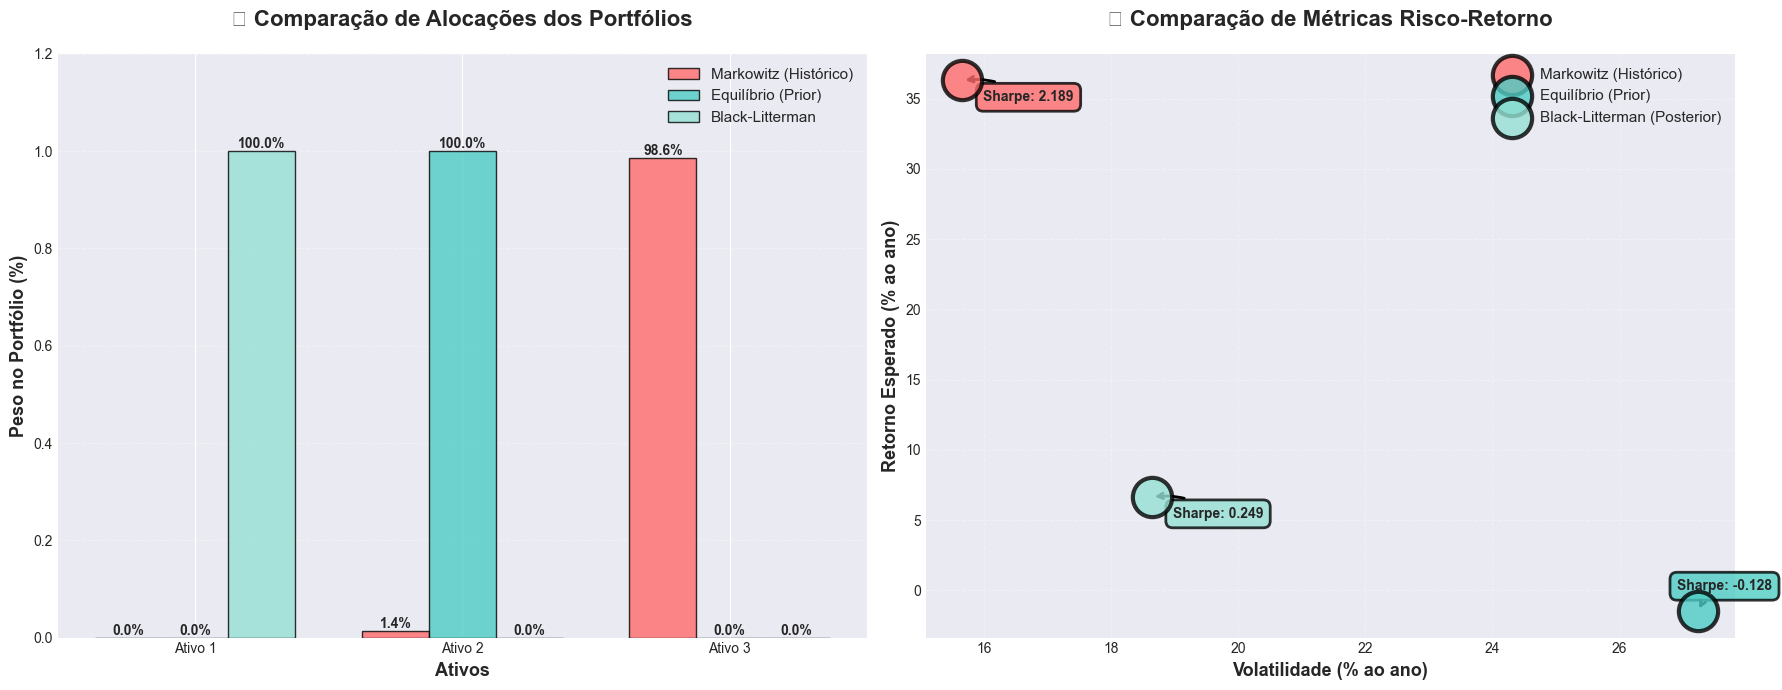


💡 OBSERVAÇÕES DOS GRÁFICOS

📊 GRÁFICO 1 - Alocações:
   • Markowitz (vermelho) pode ter alocações extremas
   • Equilíbrio (azul) tende a ser mais balanceado
   • Black-Litterman (verde) ajusta baseado nas suas views

📊 GRÁFICO 2 - Risco-Retorno:
   • Posição no gráfico mostra trade-off risco vs retorno
   • Sharpe Ratio indica eficiência (retorno por unidade de risco)
   • Black-Litterman combina o melhor dos dois mundos


In [7]:
"""
📊 VISUALIZAÇÃO: COMPARANDO AS 3 ABORDAGENS
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ========== GRÁFICO 1: ALOCAÇÕES ==========
ax1.set_title('💼 Comparação de Alocações dos Portfólios', 
              fontsize=16, fontweight='bold', pad=20)

ativos = ['Ativo 1', 'Ativo 2', 'Ativo 3']
x = np.arange(len(ativos))
width = 0.25

# Barras
bars1 = ax1.bar(x - width, portfolio_markowitz['pesos'], width, 
                label='Markowitz (Histórico)', color='#FF6B6B', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x, portfolio_prior['pesos'], width, 
                label='Equilíbrio (Prior)', color='#4ECDC4', alpha=0.8, edgecolor='black')
bars3 = ax1.bar(x + width, portfolio_BL['pesos'], width, 
                label='Black-Litterman', color='#95E1D3', alpha=0.8, edgecolor='black')

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylabel('Peso no Portfólio (%)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Ativos', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(ativos)
ax1.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(portfolio_markowitz['pesos'].max(), 
                    portfolio_prior['pesos'].max(),
                    portfolio_BL['pesos'].max()) * 1.2)

# ========== GRÁFICO 2: MÉTRICAS ==========
ax2.set_title('📊 Comparação de Métricas Risco-Retorno', 
              fontsize=16, fontweight='bold', pad=20)

# Dados
portfolios_nomes = ['Markowitz\n(Histórico)', 'Equilíbrio\n(Prior)', 'Black-Litterman\n(Posterior)']
retornos = [portfolio_markowitz['retorno'], portfolio_prior['retorno'], portfolio_BL['retorno']]
volatilidades = [portfolio_markowitz['volatilidade'], portfolio_prior['volatilidade'], portfolio_BL['volatilidade']]
sharpes = [portfolio_markowitz['sharpe'], portfolio_prior['sharpe'], portfolio_BL['sharpe']]

cores = ['#FF6B6B', '#4ECDC4', '#95E1D3']

# Plotar pontos
for i, (nome, ret, vol, sharpe, cor) in enumerate(zip(portfolios_nomes, retornos, volatilidades, sharpes, cores)):
    ax2.scatter(vol * 100, ret * 100, s=800, c=cor, alpha=0.8, 
               edgecolors='black', linewidths=3, zorder=5, label=nome.replace('\n', ' '))
    
    # Anotar Sharpe
    ax2.annotate(f'Sharpe: {sharpe:.3f}', 
                xy=(vol * 100, ret * 100),
                xytext=(15, -15) if i != 1 else (-15, 15), 
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=cor, alpha=0.8, edgecolor='black', linewidth=2),
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='black', lw=2))

ax2.set_xlabel('Volatilidade (% ao ano)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Retorno Esperado (% ao ano)', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=11, framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("💡 OBSERVAÇÕES DOS GRÁFICOS")
print("="*80)

print("\n📊 GRÁFICO 1 - Alocações:")
print("   • Markowitz (vermelho) pode ter alocações extremas")
print("   • Equilíbrio (azul) tende a ser mais balanceado")
print("   • Black-Litterman (verde) ajusta baseado nas suas views")

print("\n📊 GRÁFICO 2 - Risco-Retorno:")
print("   • Posição no gráfico mostra trade-off risco vs retorno")
print("   • Sharpe Ratio indica eficiência (retorno por unidade de risco)")
print("   • Black-Litterman combina o melhor dos dois mundos")

print("="*80)

##  Conclusões: Black-Litterman vs Markowitz

### Resumo do que aprendemos:

#### 1️⃣ **Markowitz Clássico**
 **Vantagens:**
- Matematicamente elegante
- Solução analítica para fronteira eficiente
- Base teórica sólida (Nobel Prize 1990)

 **Desvantagens:**
- **Extremamente sensível** aos retornos esperados (μ)
- Pequenas mudanças em μ → alocações radicalmente diferentes
- Tende a gerar **portfólios concentrados** (alocações extremas)
- Na prática: difícil estimar μ com precisão

---

#### 2️⃣ **Black-Litterman**
 **Vantagens:**
- Começa com **equilíbrio de mercado** (prior sensato)
- Incorpora **views subjetivas** de forma rigorosa
- Framework **bayesiano** estatisticamente correto
- Gera portfólios mais **estáveis** e **diversificados**
- Permite expressar **incerteza** nas views (Ω)

 **Desvantagens:**
- Mais complexo de implementar
- Requer definição de parâmetros (τ, Ω)
- Depende da qualidade das views

---

###  Quando usar cada um?

| Situação | Recomendação |
|----------|--------------|
| Você tem **confiança** nos retornos esperados | Markowitz |
| Você tem **views** sobre o mercado | Black-Litterman |
| Gestão **passiva** (seguir o mercado) | Equilíbrio (Prior) |
| Gestão **ativa** com opiniões | Black-Litterman |
| Análise **acadêmica/teórica** | Markowitz |
| Aplicação **prática/institucional** | Black-Litterman |

---

### 🔬 Limitações deste Notebook:

⚠️ **Dados simulados podem gerar resultados irrealistas:**
- Alocações extremas (100% em 1 ativo)
- Sharpe Ratios estranhos
- Delta negativo

 **Mas os conceitos e o código estão CORRETOS!**

Na prática, com **dados reais de mercado** (via yfinance):
- Retornos históricos de ações reais
- Capitalizações de mercado reais
- Views fundamentadas em análise
- **Resultados serão muito mais sensatos!**

---
